In [14]:
import mne
from pathlib import Path

import numpy as np

from SleepMReye.sleepmreye.extract_eog import extract_eog


subject = "17"
run = 3
subject_dir = Path("/Users/zach/2025_RA/matthias/sleepMReye/eeg")

path = Path(subject_dir) / f"sub-{subject}" / f"sub-{subject}_task-sleep_run-{run}_eeg.vhdr"

raw = mne.io.read_raw_brainvision(str(path), preload=True)
if 'EOG' in raw.ch_names:
    raw.set_channel_types({'EOG': 'eog'})
# eog = extract_eog(subject_dir=subject_dir, subject=subject, run=run, l_filter=0.1)

Extracting parameters from /Users/zach/2025_RA/matthias/sleepMReye/eeg/sub-17/sub-17_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4764799  =      0.000 ...   952.960 secs...


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_89941/1651671708.py:12: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(str(path), preload=True)


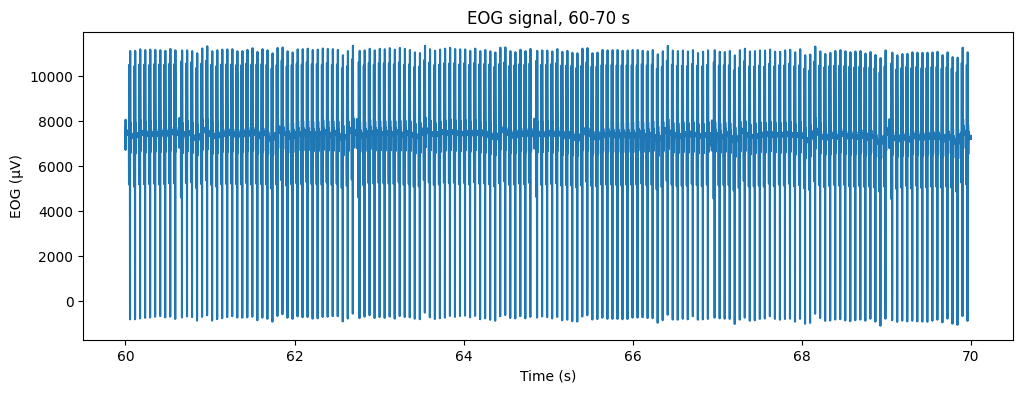

In [15]:
from matplotlib import pyplot as plt

# Get EOG channel data
eog_data, times = raw.copy().get_data(return_times=True)

# Plot a 30-second window starting at 60s
start, stop = 60, 70
mask = (times >= start) & (times < stop)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times[mask], eog_data[0, mask] * 1e6)  # convert to µV
ax.set_xlabel("Time (s)")
ax.set_ylabel("EOG (µV)")
ax.set_title(f"EOG signal, {start}-{stop} s")


In [27]:

picks = mne.pick_channels(raw.ch_names, include=["EOG"])
raw.compute_psd(picks=picks, fmin=0.1, fmax=50).plot()
# raw.compute_psd(picks=["EOG"], fmin=0.1, fmax=50).plot()


Effective window size : 0.410 (s)
Plotting power spectral density (dB=True).


ValueError: picks (NoneNone, treated as "data") yielded no channels, consider passing picks explicitly

In [46]:
import pandas as pd

dir =  Path("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/eeg")
# if rectify:
    # fname = "rectify_"
fname = f"mean_eog_reg.p"

df = pd.read_pickle(dir / fname)



<Axes: >

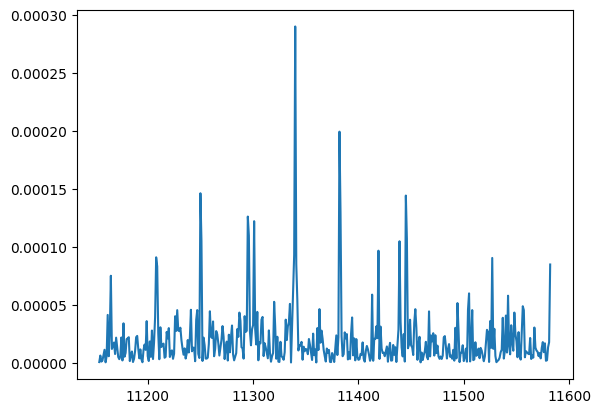

In [47]:
df[(df["subject"] == subject) & (df["run"] == str(run))]["signal"].abs().plot()

<Axes: >

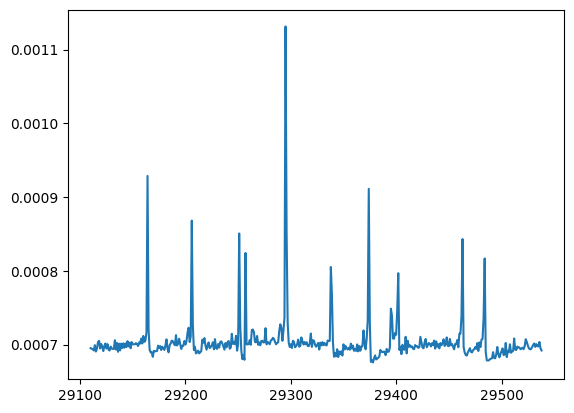

In [48]:
dfabs[(dfabs["subject"] == subject) & (dfabs["run"] == run)]['signal'].plot()

In [49]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "02", "12", "21", "07", "11", "13", "31"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    load_eog=False,
    desc_add="clean-with-fd-clamped",
)

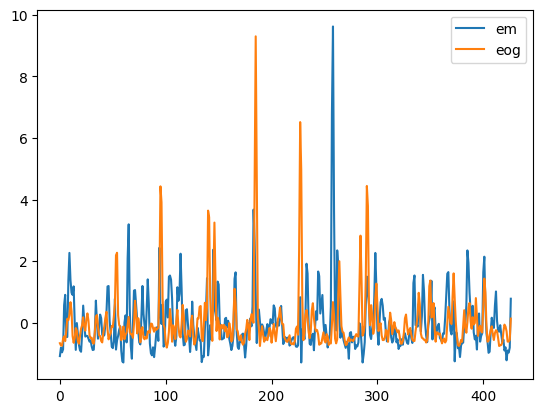

In [56]:
from scipy.stats import zscore

em, _ = mrio.load_eye_move(subject=subject, run=run)
eog = df[(df["subject"] == subject) & (df["run"] == str(run))]["signal"].reset_index(drop=True)
eog = np.abs(np.diff(eog))
eog = 0.5 * (eog[:-1] + eog[1:])
plt.plot(zscore(em), label="em")
plt.plot(zscore(eog), label="eog")
plt.legend()

In [59]:
np.corrcoef(em, eog)

array([[1.        , 0.19826969],
       [0.19826969, 1.        ]])

In [61]:
raw = mne.io.read_raw_eeglab(
      "/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/amri_eegfmri/sub-17/test.set",
      preload=True,
  )

Reading /Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/amri_eegfmri/sub-17/test.fdt
Reading 0 ... 238239  =      0.000 ...   952.956 secs...


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_89941/2374862164.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 2751 samples (11.004 s)


Text(0.5, 1.0, 'EOG signal, 60-70 s')

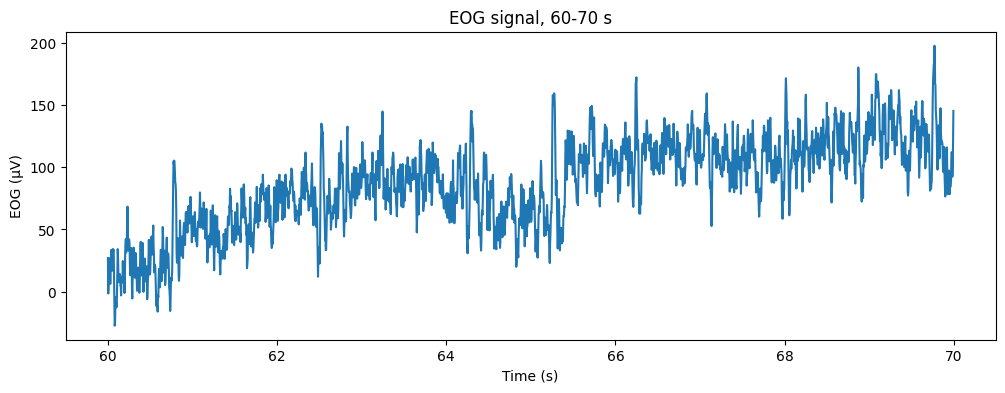

In [104]:
from matplotlib import pyplot as plt

# Get EOG channel data
raw = raw.filter(l_freq=0.3, h_freq=35, picks='EOG')
eog_data, times = raw.copy().get_data(return_times=True)

# Plot a 30-second window starting at 60s
start, stop = 60, 70
mask = (times >= start) & (times < stop)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(times[mask], eog_data[0, mask] * 1e6)  # convert to µV
ax.set_xlabel("Time (s)")
ax.set_ylabel("EOG (µV)")
ax.set_title(f"EOG signal, {start}-{stop} s")


Used Annotations descriptions: ['R', 'R128', 'S  1', 'S  2', 'S  3', 'Sync On', 'boundary']
Not setting metadata
429 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 429 events and 526 original time points ...
0 bad epochs dropped


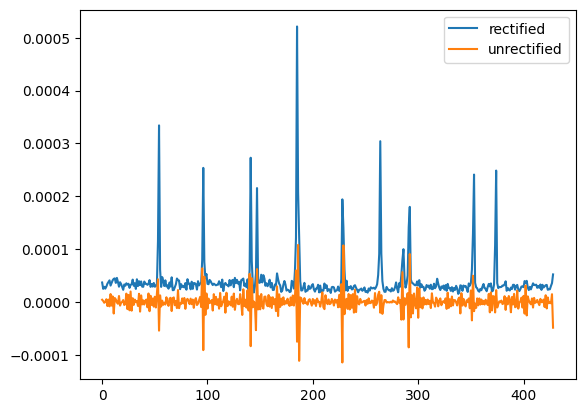

In [105]:
from SleepMReye.sleepmreye.extract_eog import extract_TR_epochs

rectify = True
epochs = extract_TR_epochs(raw, picks=["EOG"], annotation="R128")
r_signal = []
signal = []

for epoch in epochs:
    signal.append(np.mean(epoch))

for epoch in epochs:
    epoch = np.abs(epoch)
    r_signal.append(np.mean(epoch))



plt.plot(r_signal, label="rectified")
plt.plot(signal, label="unrectified")
plt.legend()
        

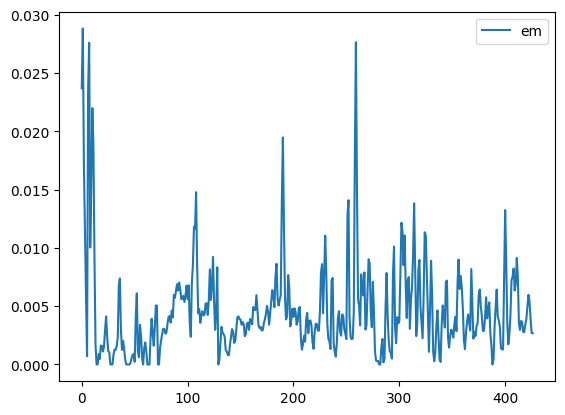

In [116]:
subject="01" 
run="1"
em, _ = mrio.load_eye_move(subject=subject, run=run)
eog = np.abs(np.diff(signal))
eog = 0.5 * (eog[:-1] + eog[1:])

r_eog = np.abs(np.diff(r_signal))
r_eog = 0.5 * (r_eog[:-1] + r_eog[1:])

plt.plot(em, label="em")
# plt.plot(zscore(eog), label="eog")
plt.legend()

In [111]:
np.corrcoef(eog, em)

array([[ 1.        , -0.02633718],
       [-0.02633718,  1.        ]])

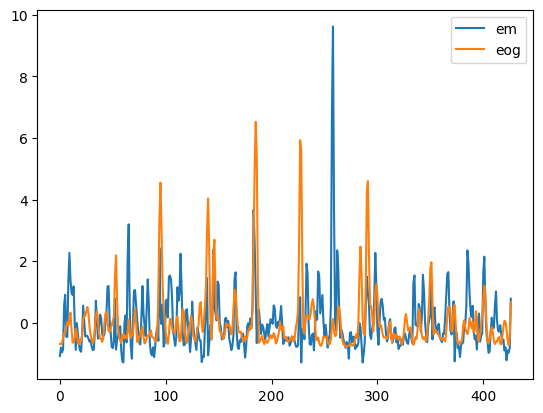

In [108]:
# eog = np.abs(np.diff(signal))
# eog = 0.5 * (eog[:-1] + eog[1:])
plt.plot(zscore(em), label="em")
plt.plot(zscore(eog), label="eog")
plt.legend()

In [85]:
np.corrcoef(eog, em)

array([[1.        , 0.20904775],
       [0.20904775, 1.        ]])

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_89941/1871075591.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(picks=["EOG"], fmin=0.1, fmax=50).plot()
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


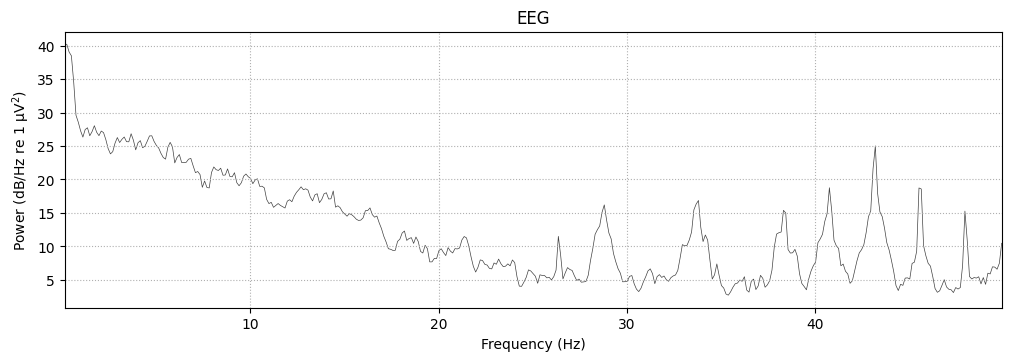

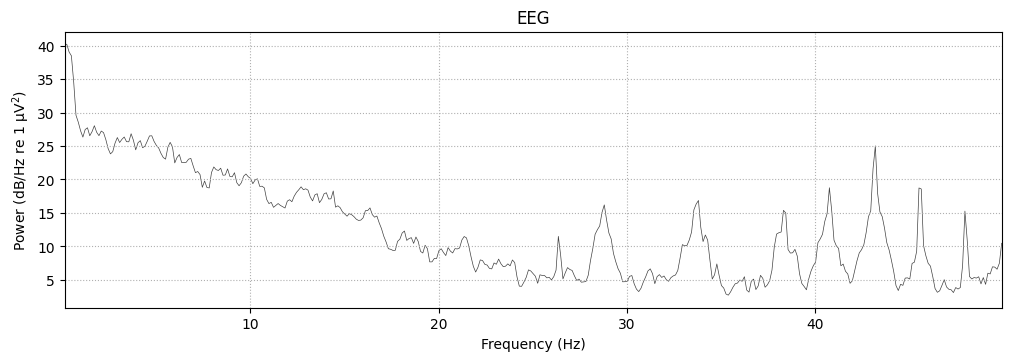

In [64]:
raw.compute_psd(picks=["EOG"], fmin=0.1, fmax=50).plot()

In [90]:
mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "02", "12", "21", "07", "11", "13", "31"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    load_eog=True,
    desc_add="clean-with-fd-clamped",
)

EOG data not full for 09, 1 (0/427). Skipping
EOG data not full for 09, 2 (0/427). Skipping
EOG data not full for 09, 3 (0/427). Skipping
EOG data not full for 09, 4 (0/427). Skipping
EOG data not full for 09, 5 (0/427). Skipping
EOG data not full for 09, 6 (0/427). Skipping
EOG data not full for 01, 1 (0/427). Skipping
EOG data not full for 01, 2 (0/427). Skipping
EOG data not full for 01, 3 (0/427). Skipping
EOG data not full for 18, 1 (0/427). Skipping
EOG data not full for 18, 2 (0/427). Skipping
EOG data not full for 18, 3 (0/427). Skipping
EOG data not full for 18, 4 (0/427). Skipping
EOG data not full for 18, 5 (0/427). Skipping
EOG data not full for 17, 6 (0/427). Skipping
EOG data not full for 16, 1 (282/427). Skipping
EOG data not full for 16, 2 (282/427). Skipping
EOG data not full for 16, 3 (293/427). Skipping
EOG data not full for 16, 4 (234/427). Skipping
EOG data not full for 16, 5 (237/427). Skipping
EOG data not full for 16, 7 (0/427). Skipping
EOG data not full for 16

In [99]:
df = mrio.events

run_has_nan = df.groupby(['subject', 'run'])['eog'].apply(lambda s: s.isna().any())
# Run counts
n_runs_with_nan    = run_has_nan.sum()
n_runs_without_nan = (~run_has_nan).sum()

# Subject counts (subject counts as "with NaN" if any of their runs has NaN)
subj_has_nan = run_has_nan.groupby(level='subject').all()
n_subjects_with_nan    = subj_has_nan.sum()
n_subjects_without_nan = (~subj_has_nan).sum()

print(f"runs:     {n_runs_without_nan} clean / {n_runs_with_nan} with NaN")
print(f"subjects: {n_subjects_without_nan} clean / {n_subjects_with_nan} with all NaN run")

runs:     146 clean / 43 with NaN
subjects: 26 clean / 5 with ≥1 NaN run


31